# Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from model_utils import calculate_metrics, evaluate_baselines, update_model_result

# Funções

In [27]:
def apresentar_estacionariedade(serie, log=True):
    resultado_adf = adfuller(serie)
    resultado_kpss = kpss(serie)
    estacionario = (resultado_adf[1] <= 0.05) and (resultado_kpss[1] > 0.05)
    if (log):
        print("="*40)
        print("Estatística ADF:", resultado_adf[0])
        print("p-valor ADF:", resultado_adf[1])
        print("p-valor KPSS:", resultado_kpss[1])
        print("É estacionário?", "Sim" if estacionario else "Não") # Se for menor igual a 0.05 significa que é estacionário
        print("Valores críticos:")
        for chave, valor in resultado_adf[4].items():
            print(f"    {chave}: {valor}")
    return estacionario
    

In [28]:
def tornar_estacionario(serie, target_column):
    diferenciacao = 0
    while not apresentar_estacionariedade(serie[target_column], False):
        diferenciacao += 1
        serie = serie.diff().dropna()
    
    return serie, diferenciacao

In [29]:
def analisar_series_temporais(df, coluna_data, figsize=(14, 5)):
    """
    Plota todas as colunas numéricas ao longo do tempo
    e gera uma matriz de correlação.

    Parameters
    ----------
    df : pandas.DataFrame
    coluna_data : str
        Nome da coluna ou do índice de data.
    """

    # Cópia para evitar alterar o dataframe original
    df_plot = df.copy()

    if coluna_data in df_plot.columns:
        df_plot[coluna_data] = pd.to_datetime(df_plot[coluna_data])
        df_plot = df_plot.sort_values(coluna_data)
        eixo_temporal = df_plot[coluna_data]
    elif df_plot.index.name == coluna_data:
        df_plot.index = pd.to_datetime(df_plot.index)
        df_plot = df_plot.sort_index()
        eixo_temporal = df_plot.index
    else:
        raise ValueError(
            f"'{coluna_data}' não foi encontrada como coluna nem como nome do índice."
        )

    # Seleciona colunas numéricas
    colunas_numericas = df_plot.select_dtypes(include=np.number).columns

    # Plota cada série temporal
    for coluna in colunas_numericas:
        plt.figure(figsize=figsize)

        plt.plot(
            eixo_temporal,
            df_plot[coluna]
        )

        plt.title(f"{coluna} ao longo do tempo")
        plt.xlabel(coluna_data)
        plt.ylabel(coluna)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Correlação
    correlacao = df_plot[colunas_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Matriz de Correlação")
    plt.tight_layout()
    plt.show()

    return correlacao

In [30]:
def calcular_vif(df, colunas=None):
    """
    Calcula o Variance Inflation Factor (VIF) para as colunas informadas.

    Parameters
    ----------
    df : pandas.DataFrame
    colunas : list[str], optional
        Colunas a serem consideradas. Se None, utiliza todas as numéricas.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo Feature e VIF.
    """

    if colunas is None:
        colunas = df.select_dtypes(include=np.number).columns.tolist()

    X = df[colunas].copy()

    # Remove linhas com NaN
    X = X.dropna()

    vif_df = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Pegando dados

In [57]:
df_raw = pd.read_csv("data/Pilgrim_s_Pride_Corporation_2.csv")

TARGET = "Close"
DATE_COLUMN = "Date"

# Ordena a série antes de qualquer divisão temporal.
df_raw[DATE_COLUMN] = pd.to_datetime(
    df_raw[DATE_COLUMN], errors="coerce", utc=True
).dt.tz_localize(None)
df_raw = df_raw.dropna(subset=[DATE_COLUMN])
df_raw = df_raw.loc[df_raw[DATE_COLUMN] >= pd.Timestamp("2013-01-01")].copy()
df_raw = (
    df_raw.set_index(DATE_COLUMN)
    .sort_index()
    .drop(columns=["Open", "High", "Low", "Volume", "USD_MXN"], errors="ignore")
)
df_raw.head(2)

,Close,TSN_Close,XLP_Close,CALM_Close
Date,,,,
2013-07-25,10.501412,20.271559,29.259361,17.716730
2013-07-26,10.520623,20.308960,29.224169,17.668276


## Estacionariedade

In [32]:
is_estacionario = apresentar_estacionariedade(df_raw[TARGET])

Estatística ADF: -1.9078356940323928
p-valor ADF: 0.3283839792041794
p-valor KPSS: 0.01
É estacionário? Não
Valores críticos:
    1%: -3.4322584870400656
    5%: -2.862383259891412
    10%: -2.5672188828198506


In [58]:
# A diferenciação será escolhida pelo auto_arima usando somente o treino.
df_estacionario = df_raw.copy()
diferenciacao = 0
print("A ordem de diferenciação será escolhida pelo auto_arima.")

A ordem de diferenciação será escolhida pelo auto_arima.


## Escalonando a base

In [59]:
from sklearn.preprocessing import StandardScaler

TEST_FRACTION = 0.25
h = int(len(df_estacionario) * TEST_FRACTION)
train_original = df_estacionario.iloc[:-h].copy()
test_original = df_estacionario.iloc[-h:].copy()

scaler = StandardScaler()
scaler.fit(train_original)

train = pd.DataFrame(
    scaler.transform(train_original),
    index=train_original.index,
    columns=train_original.columns
)
test = pd.DataFrame(
    scaler.transform(test_original),
    index=test_original.index,
    columns=test_original.columns
)
df_escalonado = pd.concat([train, test])

print(f"Treino: {len(train)} observações | Teste: {len(test)} observações")

Treino: 2573 observações | Teste: 857 observações


# Correlação

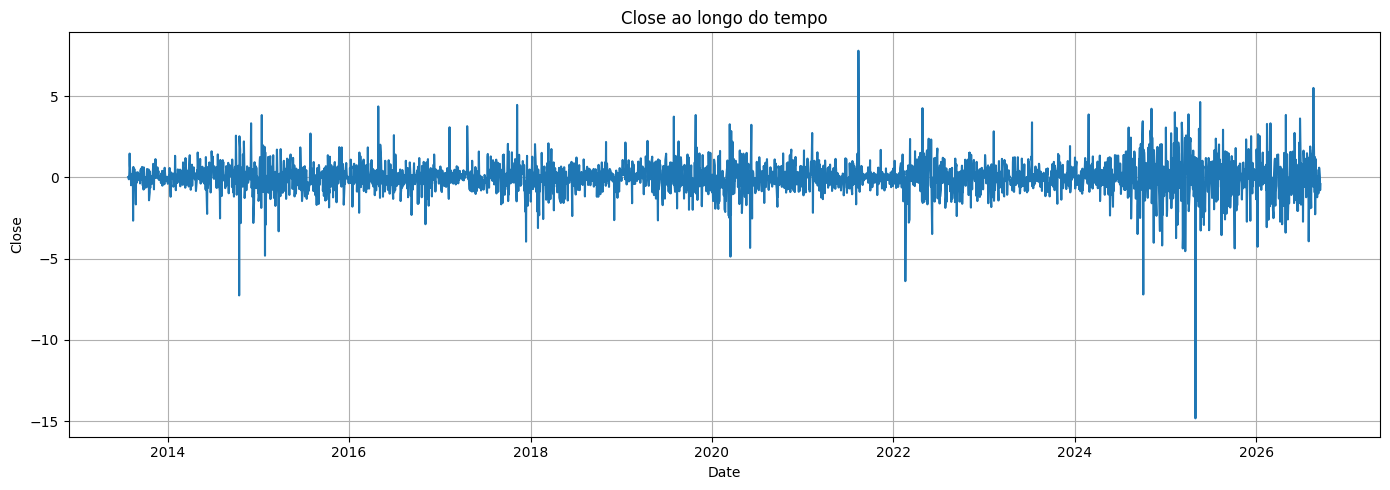

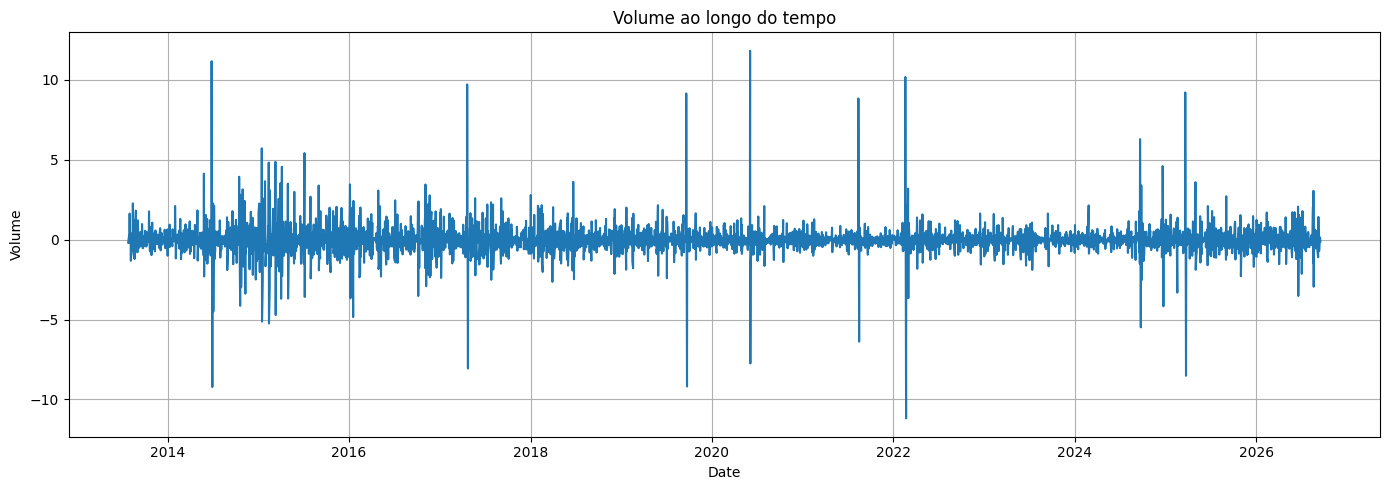

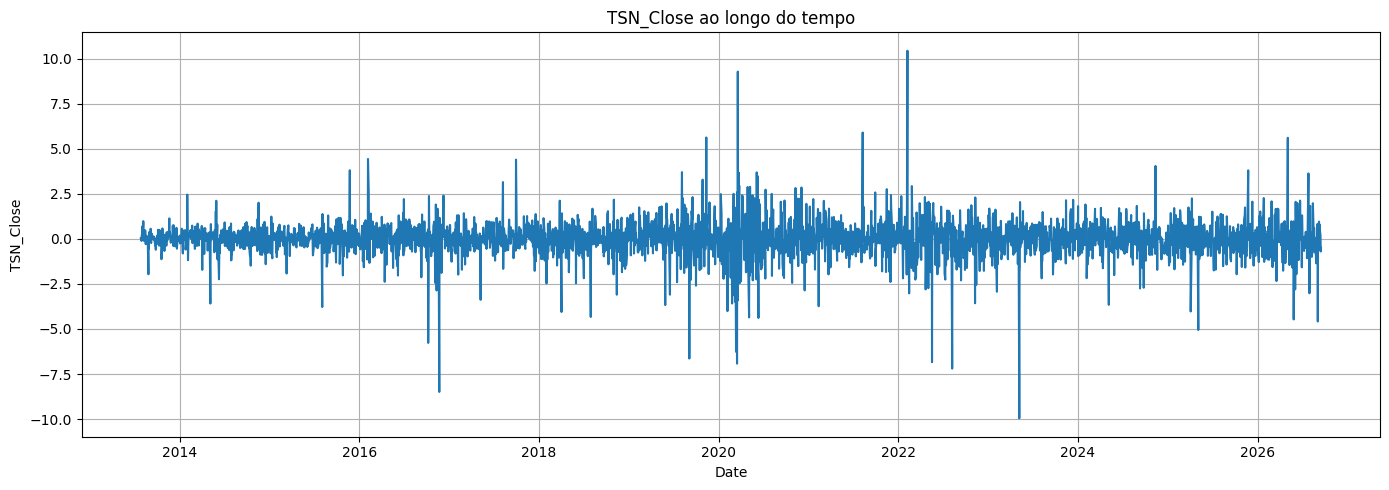

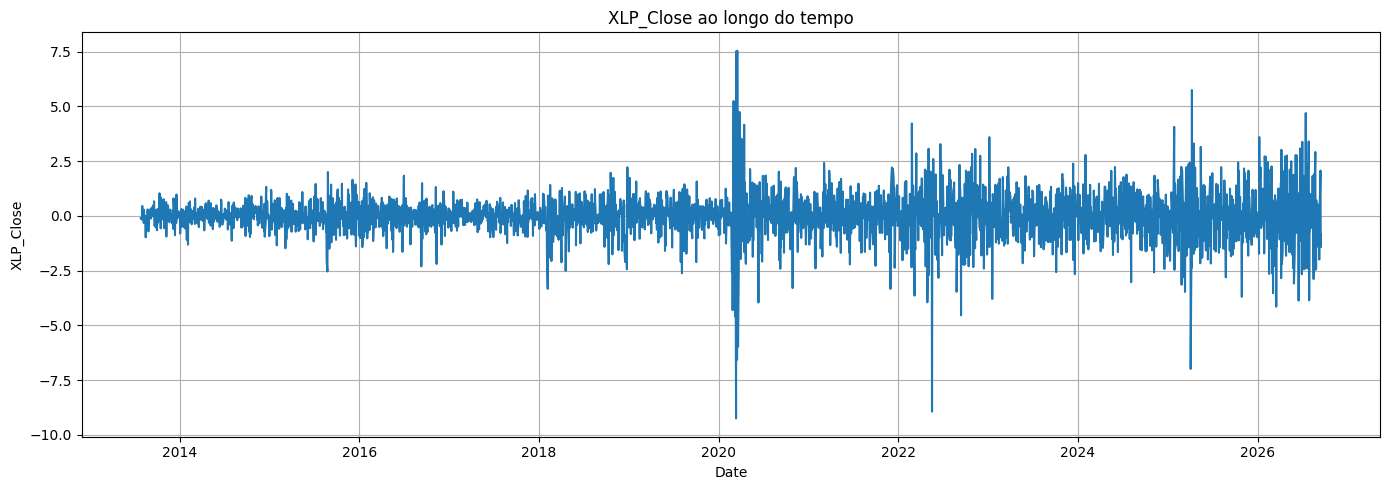

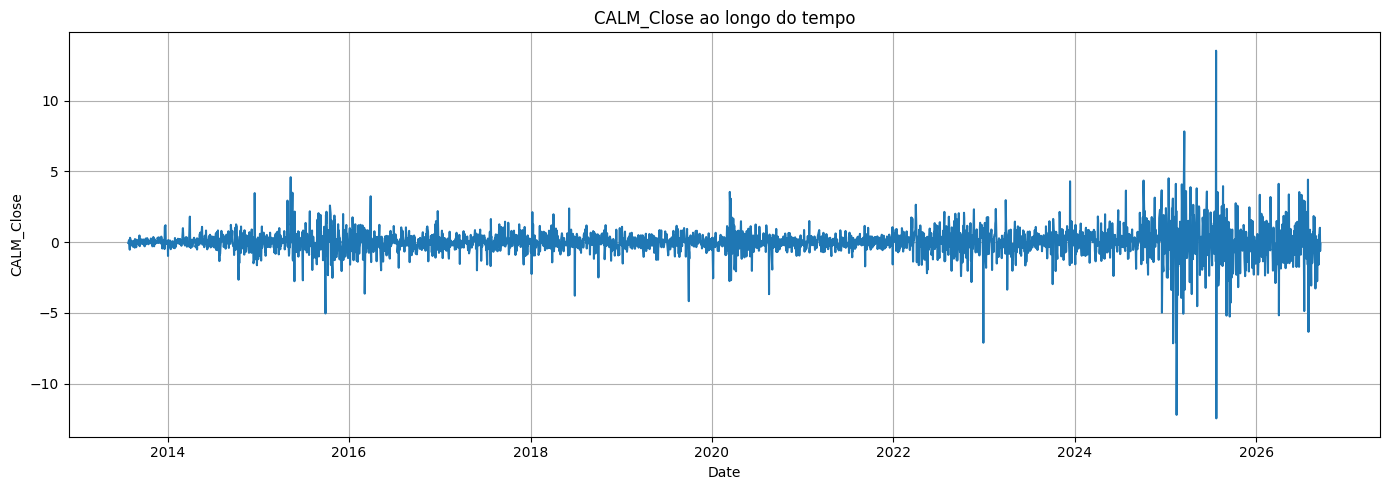

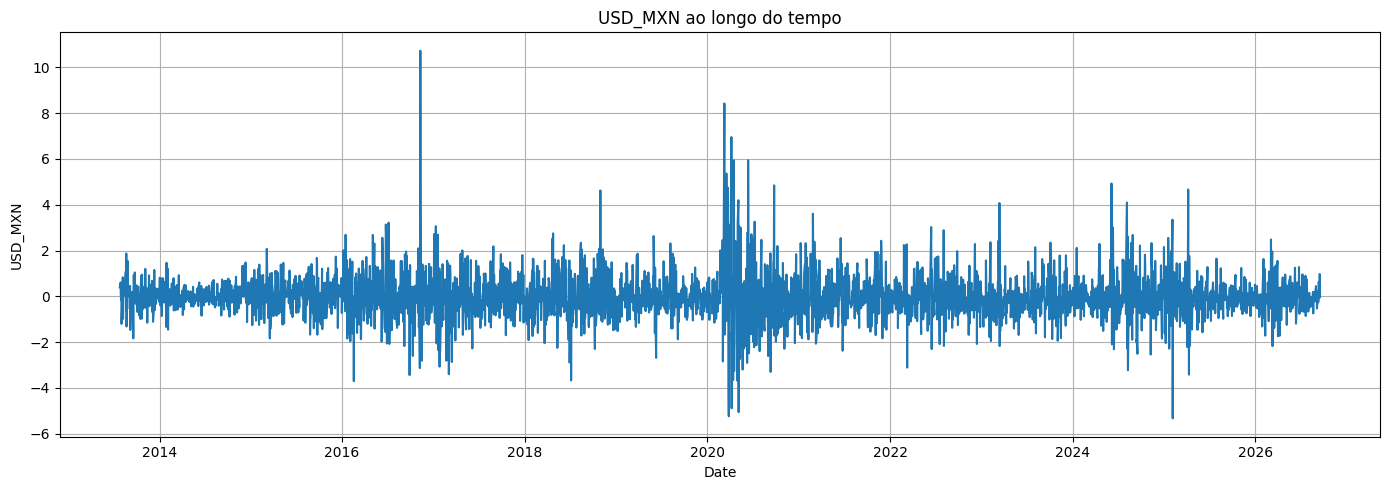

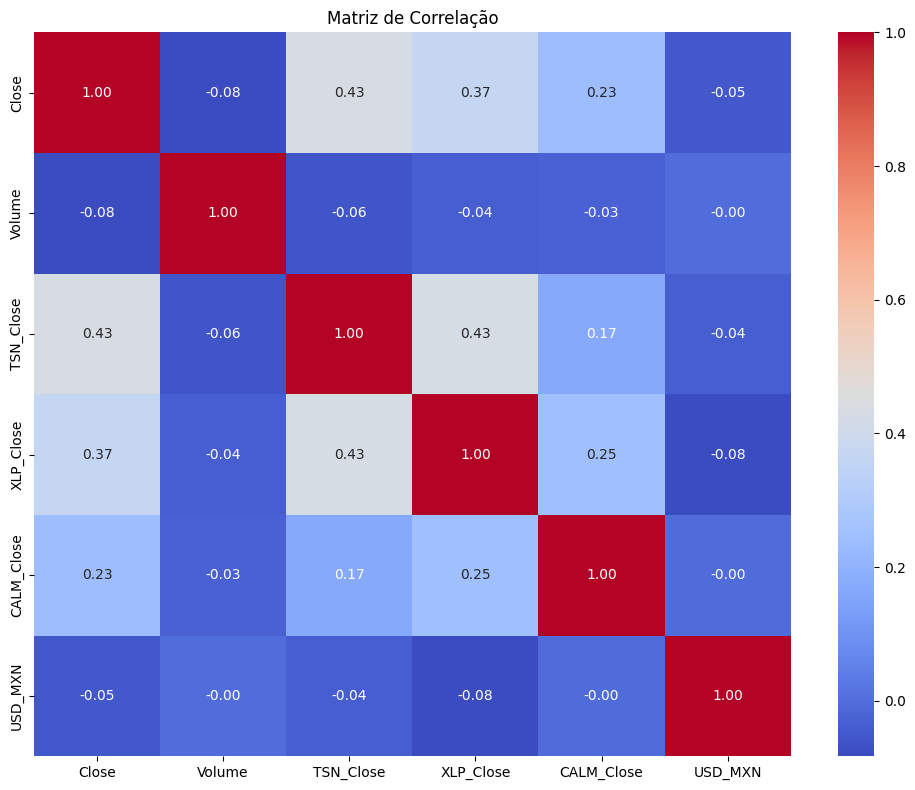

,Close,Volume,TSN_Close,XLP_Close,CALM_Close,USD_MXN
Close,1.000000,-0.082712,0.434423,0.369301,0.234640,-0.049613
Volume,-0.082712,1.000000,-0.058394,-0.036263,-0.028667,-0.000534
TSN_Close,0.434423,-0.058394,1.000000,0.430878,0.167887,-0.037862
XLP_Close,0.369301,-0.036263,0.430878,1.000000,0.245832,-0.080923
CALM_Close,0.234640,-0.028667,0.167887,0.245832,1.000000,-0.002787
USD_MXN,-0.049613,-0.000534,-0.037862,-0.080923,-0.002787,1.000000


In [35]:
analisar_series_temporais(df_escalonado, DATE_COLUMN)

> Iremos utilizar o a TSN_Close, XLP_Close e CALM_Close

In [60]:
EXOGS = ["TSN_Close", "XLP_Close", "CALM_Close"]

In [37]:
df_escalonado = df_escalonado.drop(columns=["Volume", "USD_MXN"])

# Separar treino e teste e escalonando

In [61]:
# O corte temporal já foi feito na célula de preparação.
print(f"Treino: {len(train)} observações | Teste: {len(test)} observações")

Treino: 2573 observações | Teste: 857 observações


In [ ]:
print("A base escalonada foi mantida apenas na memória; o scaler foi ajustado somente no treino.")

# PACF e ACF

<Figure size 1000x400 with 0 Axes>

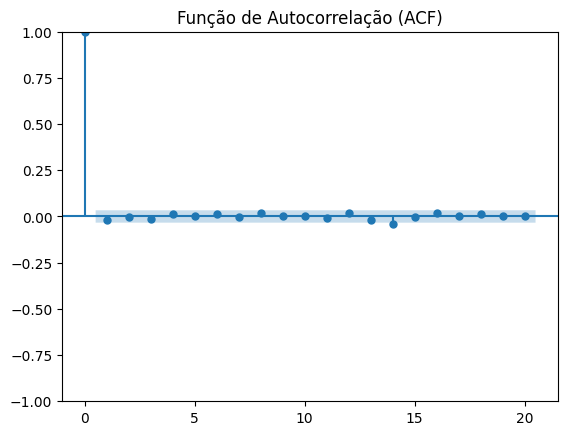

<Figure size 1000x400 with 0 Axes>

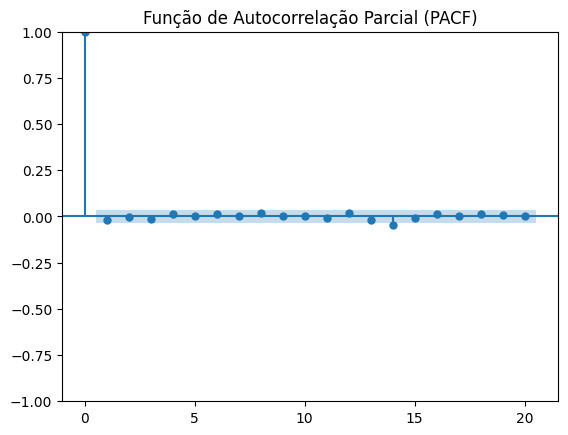

In [40]:
MAX_LAG = 20
plt.figure(figsize=[10,4])
plot_acf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação (ACF)")
plt.show()

plt.figure(figsize=[10,4])
plot_pacf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação Parcial (PACF)")
plt.show()

# STL (Força de sazonalidade)

In [41]:
# range_m = range(2, 101)
# forcas_sazonalidades = []
# qtd_ms = max(range_m)
# for m in range_m:
#     stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
#     forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
#     forcas_sazonalidades.append({"m":m, "forca":forca_sazonalidade}) 
#     print(f"[{m}/{qtd_ms}] M calculado: {forca_sazonalidade}")

# forcas_sazonalidades = sorted(forcas_sazonalidades, key=lambda x: x["forca"],reverse=True)
# forcas_sazonalidades

> Escolhido: 76

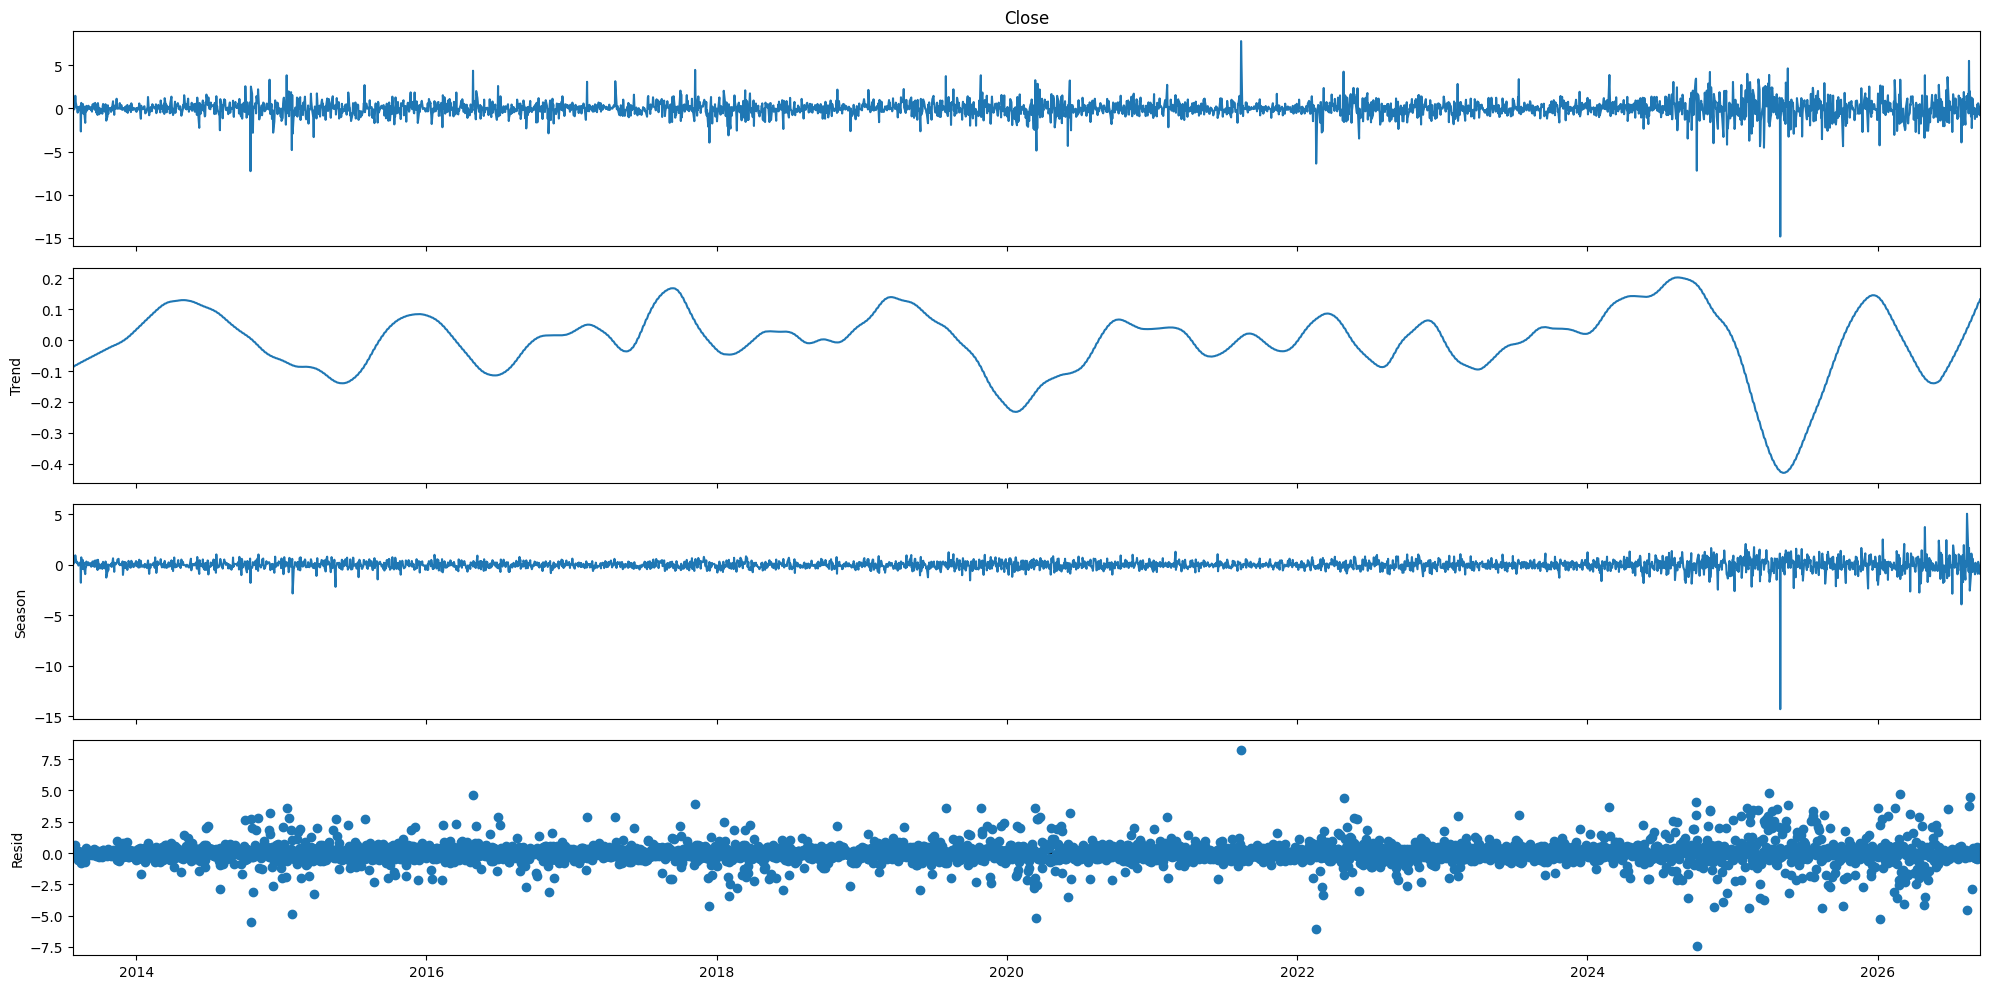

In [42]:
m = 76
stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

In [43]:
forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))

print(f"Força de sazonalidade (0-1): {forca_sazonalidade:.4f}")

Força de sazonalidade (0-1): 0.1950


In [62]:
# espaco de busca
m_final = 76

In [63]:
from pmdarima.arima import auto_arima

# Configura para testar múltiplas combinações ao mesmo tempo
model = auto_arima(
    y=train[TARGET], 
    exogenous=train[EXOGS], # Opcional (se tiver Regressores Exógenos - X)
    seasonal=True, 
    m=m_final,                     # Período sazonal (ex: 12 para mensal)
    stepwise=True,           # Força a busca dinamica
    n_jobs=-1,                # Usa TODOS os núcleos do seu processador em paralelo
    trace=True                # Mostra o progresso na tela
)

# (2,0,2)(0,0,0)[76]

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[76] intercept   : AIC=-4666.764, Time=98.75 sec
 ARIMA(0,1,0)(0,0,0)[76] intercept   : AIC=-4664.044, Time=0.35 sec
 ARIMA(1,1,0)(1,0,0)[76] intercept   : AIC=-4663.180, Time=28.25 sec
 ARIMA(0,1,1)(0,0,1)[76] intercept   : AIC=-4662.976, Time=18.99 sec
 ARIMA(0,1,0)(0,0,0)[76]             : AIC=-4665.880, Time=0.21 sec
 ARIMA(2,1,2)(0,0,1)[76] intercept   : AIC=-4668.740, Time=103.29 sec
 ARIMA(2,1,2)(0,0,0)[76] intercept   : AIC=-4670.696, Time=1.65 sec
 ARIMA(2,1,2)(1,0,0)[76] intercept   : AIC=-4668.739, Time=112.86 sec
 ARIMA(1,1,2)(0,0,0)[76] intercept   : AIC=-4669.846, Time=1.13 sec
 ARIMA(2,1,1)(0,0,0)[76] intercept   : AIC=-4669.739, Time=1.24 sec
 ARIMA(3,1,2)(0,0,0)[76] intercept   : AIC=-4670.441, Time=2.18 sec
 ARIMA(2,1,3)(0,0,0)[76] intercept   : AIC=-4670.381, Time=2.44 sec
 ARIMA(1,1,1)(0,0,0)[76] intercept   : AIC=-4670.517, Time=0.96 sec
 ARIMA(1,1,3)(0,0,0)[76] intercept   : AIC=-4669.484, Time=0.74 se

In [64]:
print("Parâmetros selecionados pelo auto_arima:")
print("order:", model.order)
print("seasonal_order:", model.seasonal_order)

Parâmetros selecionados pelo auto_arima:
order: (2, 1, 2)
seasonal_order: (0, 0, 0, 76)


In [68]:
WALK_FORWARD_STEP = 50
melhores_parametros = [list(model.order), list(model.seasonal_order)]

# Ajuste final no treino completo para diagnóstico e explicação SHAP.
melhor_modelo = SARIMAX(
    train[TARGET],
    exog=train[EXOGS],
    order=model.order,
    seasonal_order=model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = melhor_modelo.fit(disp=False, maxiter=100)

# Avaliação walk-forward com janela expansiva e refit periódico.
historico = train.copy()
previsoes_walk_forward = []
for inicio in range(0, len(test), WALK_FORWARD_STEP):
    fim = min(inicio + WALK_FORWARD_STEP, len(test))
    modelo_wf = SARIMAX(
        historico[TARGET],
        exog=historico[EXOGS],
        order=model.order,
        seasonal_order=model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=100)
    previsoes_bloco = modelo_wf.forecast(
        steps=fim - inicio,
        exog=test[EXOGS].iloc[inicio:fim]
    )
    previsoes_walk_forward.extend(previsoes_bloco.to_numpy())
    historico = pd.concat([historico, test.iloc[inicio:fim]])

fc_melhor_escalonado = pd.Series(previsoes_walk_forward, index=test.index)
target_posicao = list(train.columns).index(TARGET)
fc_melhor = pd.Series(
    fc_melhor_escalonado.to_numpy() * scaler.scale_[target_posicao]
    + scaler.mean_[target_posicao],
    index=test_original.index,
    name=TARGET
)
metrics_sarimax = calculate_metrics(test_original[TARGET], fc_melhor)
baselines_sarimax = evaluate_baselines(train_original[TARGET], test_original[TARGET], m_final)

print("Parâmetros do melhor modelo:", melhores_parametros)
print("Walk-forward: refit a cada", WALK_FORWARD_STEP, "observações")
print("Métricas SARIMAX walk-forward:", metrics_sarimax)
print("Baselines:", baselines_sarimax)

Parâmetros do melhor modelo: [[2, 1, 2], [0, 0, 0, 76]]
Walk-forward: refit a cada 50 observações
Métricas SARIMAX walk-forward: {'mae': 1.836465253769307, 'rmse': 2.4193047520192708, 'mape': 5.369145278348611, 'smape': 5.299811047409916, 'wape': 5.383766013773956}
Baselines: {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}


## Análise de resíduos e importância das variáveis

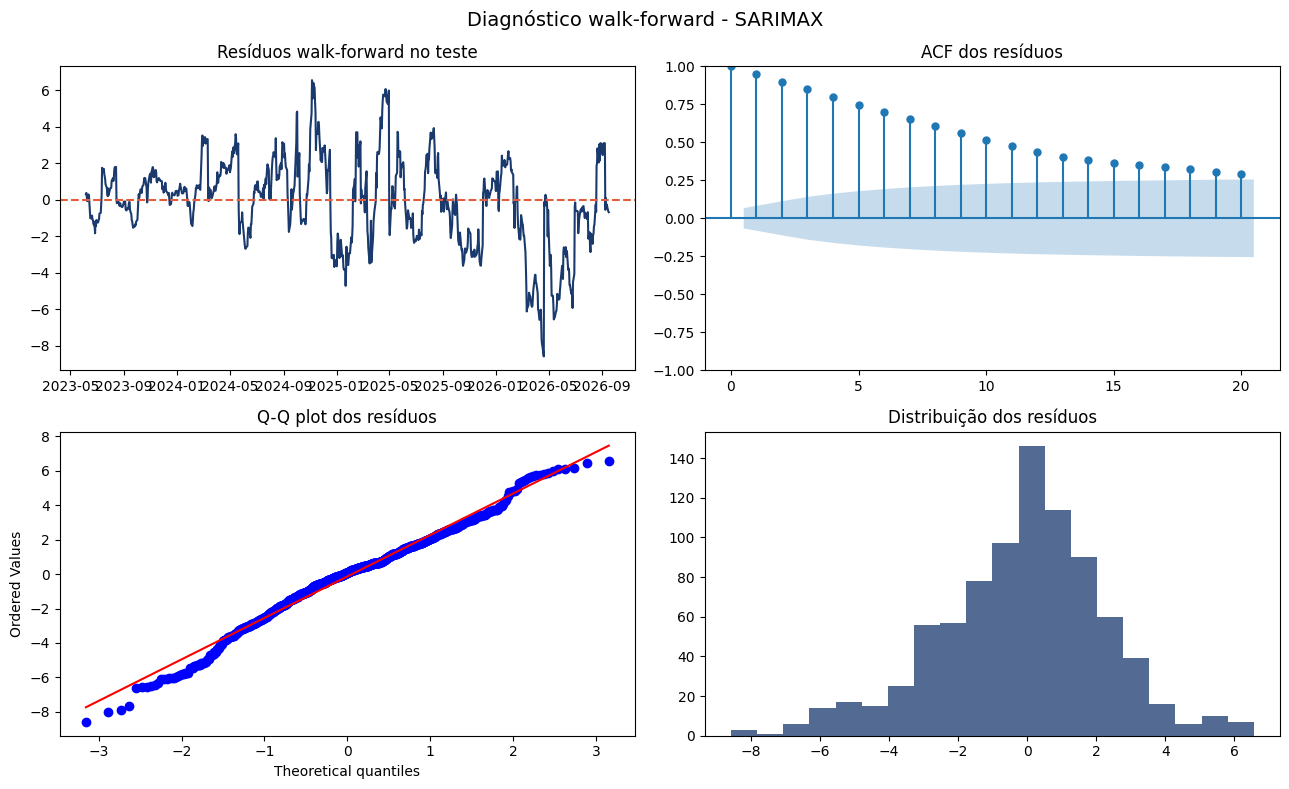

Métricas walk-forward: {'mae': 1.836465253769307, 'rmse': 2.4193047520192708, 'mape': 5.369145278348611, 'smape': 5.299811047409916, 'wape': 5.383766013773956}


,lb_stat,lb_pvalue
1,775.0096,0.0
2,1469.1462,0.0
3,2090.0025,0.0
4,2637.8904,0.0
5,3121.1827,0.0
6,3546.2185,0.0
7,3919.3497,0.0
8,4241.1156,0.0
9,4514.9531,0.0
10,4746.0316,0.0


ExactExplainer explainer: 101it [00:21,  3.77it/s]                         

Importância SHAP dos exógenos do SARIMAX:


,mean_abs_shap
XLP_Close,1.599743
TSN_Close,1.023186
CALM_Close,0.359483


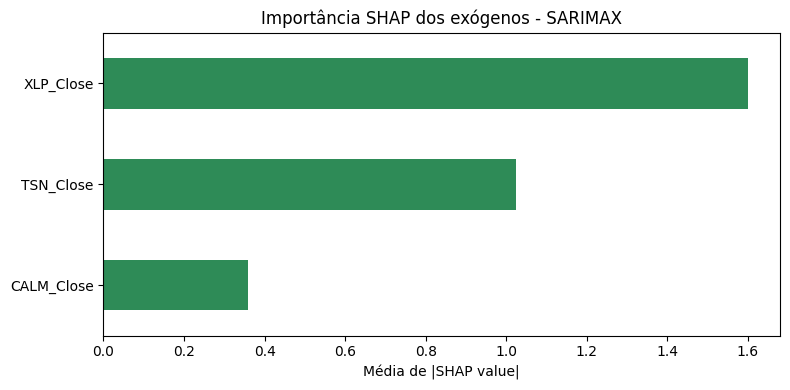

In [69]:
import shap
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos_teste = pd.Series(
    test_original[TARGET].to_numpy() - fc_melhor.to_numpy(),
    index=test_original.index,
    name="residuo"
).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(residuos_teste.index, residuos_teste, color="#1a3a6e")
axes[0, 0].axhline(0, color="#e25c3e", linestyle="--")
axes[0, 0].set_title("Resíduos walk-forward no teste")
plot_acf(residuos_teste, lags=min(20, len(residuos_teste) - 2), ax=axes[0, 1], title="ACF dos resíduos")
stats.probplot(residuos_teste, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot dos resíduos")
axes[1, 1].hist(residuos_teste, bins=20, color="#1a3a6e", alpha=0.75)
axes[1, 1].set_title("Distribuição dos resíduos")
plt.suptitle("Diagnóstico walk-forward - SARIMAX", fontsize=14)
plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(
    residuos_teste, lags=min(12, len(residuos_teste) // 5), return_df=True
)
print("Métricas walk-forward:", metrics_sarimax)
display(ljung_box[["lb_stat", "lb_pvalue"]].round(4))

# SHAP exato para os três exógenos, usando o SARIMAX ajustado no treino.
def prever_com_exogenas(valores):
    valores_df = pd.DataFrame(valores, columns=EXOGS)
    previsao = res.get_forecast(
        steps=len(valores_df), exog=valores_df
    ).predicted_mean
    return previsao.to_numpy()

background = train[EXOGS].iloc[:min(50, len(train))]
amostra_shap = test[EXOGS].iloc[:min(100, len(test))]
explainer_shap = shap.Explainer(prever_com_exogenas, background)
shap_values = explainer_shap(amostra_shap)
importancias_shap_sarimax = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=EXOGS
).sort_values(ascending=False)
print("Importância SHAP dos exógenos do SARIMAX:")
display(importancias_shap_sarimax.rename("mean_abs_shap").to_frame())
plt.figure(figsize=(8, 4))
importancias_shap_sarimax.sort_values().plot(kind="barh", color="#2e8b57")
plt.title("Importância SHAP dos exógenos - SARIMAX")
plt.xlabel("Média de |SHAP value|")
plt.tight_layout()
plt.show()

In [70]:
resultado_sarimax = update_model_result(
    "all_modelos.json",
    "Sarimax",
    metrics_sarimax,
    params={"order": melhores_parametros[0], "seasonal_order": melhores_parametros[1]},
    extra={
        "baselines": baselines_sarimax,
        "walk_forward_step": WALK_FORWARD_STEP,
        "shap_importance": importancias_shap_sarimax.head(20).to_dict()
    }
)
print(resultado_sarimax)

{'modelo': 'Sarimax', 'mae': 1.836465253769307, 'rmse': 2.4193047520192708, 'mape': 5.369145278348611, 'smape': 5.299811047409916, 'wape': 5.383766013773956, 'params': {'order': [2, 1, 2], 'seasonal_order': [0, 0, 0, 76]}, 'baselines': {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}, 'walk_forward_step': 50, 'shap_importance': {'XLP_Close': 1.5997433956202738, 'TSN_Close': 1.023185680182377, 'CALM_Close': 0.359482861587696}}
